<a href="https://colab.research.google.com/github/catdlia/-/blob/main/experimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика

## Інсталяція залежностей та налаштування середовища



In [40]:
!pip install catboost optuna lightgbm xgboost

import os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## Робота з файловою системою та завантаження вибірок

In [41]:
from pathlib import Path
import pandas as pd
import numpy as np

# Головна робоча папка проекту на твоєму Google Диску
DATA_DIR = Path('/content/drive/MyDrive/GCI/competition')

# Шляхи до вхідних даних змагання
TRAIN_PATH = DATA_DIR / 'input/train.csv'
TEST_PATH = DATA_DIR / 'input/test.csv'
SUB_PATH = DATA_DIR / 'input/sample_submission.csv'

# Шляхи до CSV-файлів із параметрами, які ти завантажив із Kaggle
CB_PARAMS_PATH = DATA_DIR / 'optuna_best_cb_params_night.csv'
LGB_PARAMS_PATH = DATA_DIR / 'optuna_best_lgb_params.csv'
XGB_PARAMS_PATH = DATA_DIR / 'optuna_best_xgb_params.csv'

# Завантаження датасетів
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

y = train['Drafted']
X_train_raw = train.drop(['Drafted'], axis=1)

print(f"✅ Дані завантажено. Train: {X_train_raw.shape}, Test: {test.shape}")

✅ Дані завантажено. Train: (2781, 15), Test: (696, 15)


## Блок аналітики та дослідження даних (EDA)

--- Співвідношення класів цільової змінної ---
Drafted
1.0    0.648328
0.0    0.351672
Name: proportion, dtype: float64

--- Виявлені пропуски в числових та категоріальних ознаках ---
Age                 435
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Agility_3cone       970
Shuttle             912
dtype: int64


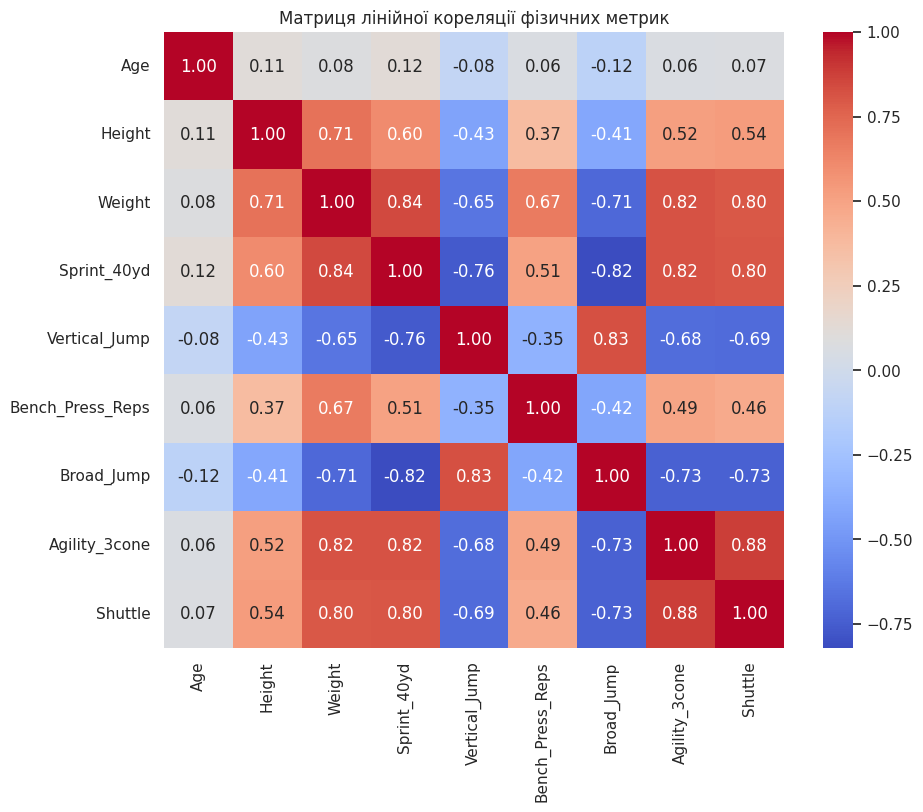


--- Кардинальність категоріальних ознак ---
School: 236 унікальних значень
Player_Type: 3 унікальних значень
Position_Type: 7 унікальних значень
Position: 20 унікальних значень


In [42]:
print("--- Співвідношення класів цільової змінної ---")
print(y.value_counts(normalize=True))

print("\n--- Виявлені пропуски в числових та категоріальних ознаках ---")
missing_data = X_train_raw.isnull().sum()
print(missing_data[missing_data > 0])

num_features = X_train_raw.select_dtypes(include=[np.number]).columns.drop(['Id', 'Year']).tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_raw[num_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матриця лінійної кореляції фізичних метрик")
plt.show()

cat_features = ['School', 'Player_Type', 'Position_Type', 'Position']
print("\n--- Кардинальність категоріальних ознак ---")
for col in cat_features:
    print(f"{col}: {X_train_raw[col].nunique()} унікальних значень")

## "Kitchen Sink" Препроцесинг та Feature Engineering



In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Збираємо дані
X_train_raw['is_train'] = 1
test['is_train'] = 0
df = pd.concat([X_train_raw, test], ignore_index=True)

# Заповнення пропусків
cat_features_base = ['School', 'Position_Type', 'Position', 'Player_Type']
for col in cat_features_base:
    df[col] = df[col].fillna('Unknown').astype(str)

# 1. СИРІ ІНЖЕНЕРНІ ФІЧІ
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['Speed_Score'] = (df['Weight'] * 200) / (df['Sprint_40yd'] ** 4)
df['Jump_Power'] = df['Vertical_Jump'] * df['Broad_Jump']

# 2. ПРОЦЕНТИЛІ (Але ми НЕ видаляємо оригінальні колонки)
num_cols = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
for col in num_cols:
    df[f'{col}_Pos_Pct'] = df.groupby('Position')[col].rank(pct=True)

# 3. PCA (Шукаємо приховані вектори фізики)
pca_data = df[num_cols].fillna(df[num_cols].mean())
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_features = pca.fit_transform(pca_scaled)
df['PCA_1_Explosiveness'] = pca_features[:, 0]
df['PCA_2_Mass'] = pca_features[:, 1]

# 4. ВЕЛИКА ЧИСТКА (Видаляємо тільки технічне сміття)
cols_to_drop = ['is_train', 'Id', 'Player_Type'] # Залишили Broad_Jump та всі сирі фічі!

X_train_v3 = df[df['is_train'] == 1].drop(cols_to_drop, axis=1)
X_test_v3 = df[df['is_train'] == 0].drop(cols_to_drop, axis=1)

print(f"✅ Kitchen Sink FE завершено! Нова розмірність: {X_train_v3.shape}")

✅ Kitchen Sink FE завершено! Нова розмірність: (2781, 26)


## Завантажуємо параметри в код

In [44]:
cb_params_df = pd.read_csv(CB_PARAMS_PATH)
lgb_params_df = pd.read_csv(LGB_PARAMS_PATH)
xgb_params_df = pd.read_csv(XGB_PARAMS_PATH)

cb_params = cb_params_df.iloc[0].to_dict()
lgb_params = lgb_params_df.iloc[0].to_dict()
xgb_params = xgb_params_df.iloc[0].to_dict()

# Функція для виправлення типів (перетворює 6.0 на 6 для дискретних параметрів)
def fix_types(params):
    for k, v in params.items():
        if isinstance(v, float) and v.is_integer():
            params[k] = int(v)
    return params

cb_params = fix_types(cb_params)
lgb_params = fix_types(lgb_params)
xgb_params = fix_types(xgb_params)

# Додаємо технічні параметри для запуску в Colab
cb_params.update({'eval_metric': 'AUC', 'random_seed': RANDOM_STATE, 'verbose': False, 'thread_count': -1})
lgb_params.update({'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1})
xgb_params.update({'tree_method': 'hist', 'enable_categorical': True, 'random_state': RANDOM_STATE, 'n_jobs': -1})

print("✅ Усі оптимальні параметри завантажено та підготовлено до стекінгу!")

✅ Усі оптимальні параметри завантажено та підготовлено до стекінгу!


## Навчання найкращої моделі та створення сабміту


In [45]:
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import RidgeCV # <-- НОВА МЕТА-МОДЕЛЬ

print("🛠 Генерація K-Fold Target Encoding для School...")

X_train_v3['School_Target_Enc'] = 0.0
X_test_v3['School_Target_Enc'] = 0.0

kf_enc = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
global_mean = y.mean()

for tr_idx, val_idx in kf_enc.split(X_train_v3):
    X_tr, X_val = X_train_v3.iloc[tr_idx], X_train_v3.iloc[val_idx]
    y_tr = y.iloc[tr_idx]
    school_means = y_tr.groupby(X_tr['School']).mean()
    X_train_v3.loc[val_idx, 'School_Target_Enc'] = X_val['School'].map(school_means)

global_school_means = y.groupby(X_train_v3['School']).mean()
X_test_v3['School_Target_Enc'] = X_test_v3['School'].map(global_school_means)

X_train_v3['School_Target_Enc'] = X_train_v3['School_Target_Enc'].fillna(global_mean)
X_test_v3['School_Target_Enc'] = X_test_v3['School_Target_Enc'].fillna(global_mean)

print("🚀 Навчання Ансамблю v3 (Kitchen Sink)...")

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_cb = np.zeros(len(X_train_v3))
oof_lgb = np.zeros(len(X_train_v3))
oof_xgb = np.zeros(len(X_train_v3))

test_cb = np.zeros(len(X_test_v3))
test_lgb = np.zeros(len(X_test_v3))
test_xgb = np.zeros(len(X_test_v3))

cat_features_cb = ['School', 'Position_Type', 'Position']
cat_features_tree = ['Position_Type', 'Position']

for col in cat_features_tree:
    X_train_v3[col] = X_train_v3[col].astype('category')
    X_test_v3[col] = X_test_v3[col].astype('category')

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train_v3, y)):
    X_tr, y_tr = X_train_v3.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_train_v3.iloc[valid_idx], y.iloc[valid_idx]

    # ІЗОЛЯЦІЯ ДАНИХ
    X_tr_cb = X_tr.drop(['School_Target_Enc'], axis=1)
    X_va_cb = X_va.drop(['School_Target_Enc'], axis=1)
    X_test_cb = X_test_v3.drop(['School_Target_Enc'], axis=1)

    X_tr_tree = X_tr.drop(['School'], axis=1)
    X_va_tree = X_va.drop(['School'], axis=1)
    X_test_tree = X_test_v3.drop(['School'], axis=1)

    # 1. CATBOOST
    train_pool = Pool(X_tr_cb, y_tr, cat_features=cat_features_cb)
    valid_pool = Pool(X_va_cb, y_va, cat_features=cat_features_cb)
    model_cb = CatBoostClassifier(**cb_params)
    model_cb.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=100)
    oof_cb[valid_idx] = model_cb.predict_proba(X_va_cb)[:, 1]
    test_cb += model_cb.predict_proba(X_test_cb)[:, 1] / N_SPLITS

    # 2. LIGHTGBM
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_tr_tree, y_tr, eval_set=[(X_va_tree, y_va)], eval_metric='auc', callbacks=[lgb.early_stopping(100, verbose=False)])
    oof_lgb[valid_idx] = model_lgb.predict_proba(X_va_tree)[:, 1]
    test_lgb += model_lgb.predict_proba(X_test_tree)[:, 1] / N_SPLITS

    # 3. XGBOOST
    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_tr_tree, y_tr, eval_set=[(X_va_tree, y_va)], verbose=False)
    oof_xgb[valid_idx] = model_xgb.predict_proba(X_va_tree)[:, 1]
    test_xgb += model_xgb.predict_proba(X_test_tree)[:, 1] / N_SPLITS

print("\n🧠 Навчання RidgeCV Мета-Моделі (Level 1)...")
X_meta_train = np.column_stack([oof_cb, oof_lgb, oof_xgb])
X_meta_test = np.column_stack([test_cb, test_lgb, test_xgb])

# RidgeCV автоматично знайде ідеальний баланс (alpha) між 0.1, 1.0 та 10.0
meta_model = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
meta_model.fit(X_meta_train, y)

# Оскільки Ridge видає неперервні значення, ми їх просто кліпаємо в діапазон [0, 1]
final_oof_preds = np.clip(meta_model.predict(X_meta_train), 0, 1)
final_test_preds = np.clip(meta_model.predict(X_meta_test), 0, 1)

final_cv_auc = roc_auc_score(y, final_oof_preds)
print(f"🏆 Kitchen Sink Stacking OOF ROC-AUC: {final_cv_auc:.5f}")
print(f"Обрана регуляризація (Alpha): {meta_model.alpha_}")
print(f"Ваги мета-моделі (CatBoost, LightGBM, XGBoost): {meta_model.coef_}")

# Сабміт
submission = sample_sub.copy()
submission['Drafted'] = final_test_preds
OUTPUT_PATH = DATA_DIR / 'kitchen_sink_ridge_submission.csv'
submission.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Збережено: {OUTPUT_PATH.resolve()}")

🛠 Генерація K-Fold Target Encoding для School...
🚀 Навчання Ансамблю v3 (Kitchen Sink)...

🧠 Навчання RidgeCV Мета-Моделі (Level 1)...
🏆 Kitchen Sink Stacking OOF ROC-AUC: 0.84229
Обрана регуляризація (Alpha): 0.1
Ваги мета-моделі (CatBoost, LightGBM, XGBoost): [0.21724683 0.13219354 0.77420508]
✅ Збережено: /content/drive/MyDrive/GCI/competition/kitchen_sink_ridge_submission.csv


🔍 Генерація SHAP-значень для оптимізованого CatBoost...


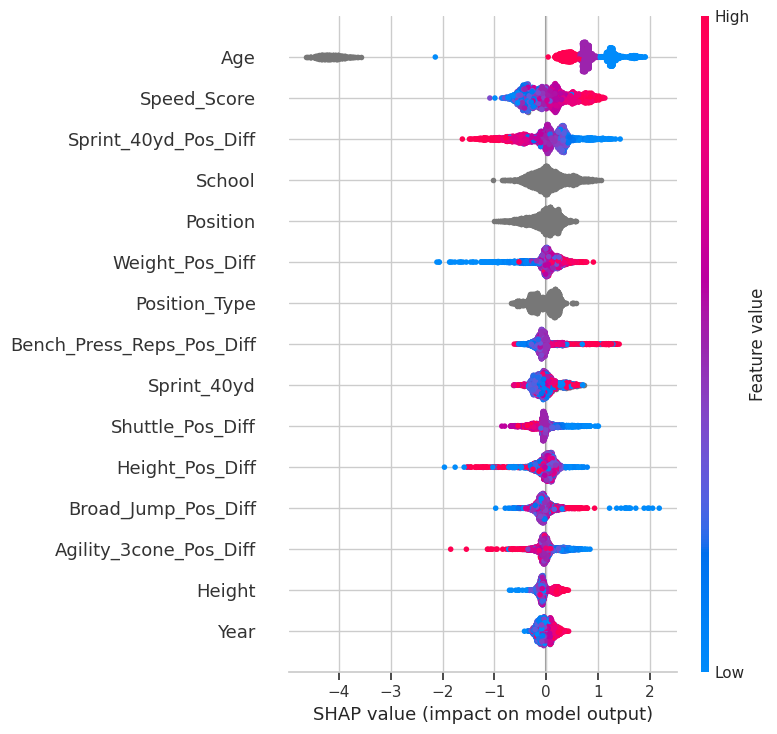

In [46]:
!pip install shap
import shap

print("🔍 Генерація SHAP-значень для оптимізованого CatBoost...")

# Навчаємо модель на всьому трейні для фінального аналізу
# Беремо дані для CatBoost (без Target_Enc)
X_cb_full = X_train.drop(['School_Target_Enc'], axis=1)

final_cb_pool = Pool(X_cb_full, y, cat_features=cat_features_cb)
final_cb = CatBoostClassifier(**cb_params)
final_cb.fit(final_cb_pool)

# Створюємо SHAP explainer
explainer = shap.TreeExplainer(final_cb)
shap_values = explainer.shap_values(final_cb_pool)

# Будуємо головний графік (Summary Plot)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_cb_full, max_display=15)

## Опис ходу думок та інженерного підходу

### 1. Еволюція Feature Engineering та Feature Selection
Під час первинної розробки ознак було створено ряд агрегацій на основі позицій гравців (відхилення від середнього та самі середні значення). Проте аналіз вбудованої метрики **Feature Importance** (на базі CatBoost) показав проблему перенасичення шумом (feature bloat): ознаки типу `*_Pos_Mean` мали вплив менше ніж 0.8%, розмиваючи дерева рішень, оскільки константне середнє не допомагає розрізняти гравців всередині однієї позиції. Видалення цих ознак та залишення лише `*_Pos_Diff` (відхилення), а також метрик вибуховості (`Speed_Score`, `Jump_Power`) дозволило моделі краще генералізувати дані та підняло скор на Public LB.

### 2. Стратегія ансамблювання: Від Blending до Stacking
Початковий експеримент із простим усередненням ймовірностей (Blending) трьох фреймворків (CatBoost, LightGBM, XGBoost) призвів до падіння загального результату. Це сталося через незбалансованість: CatBoost, завдяки нативній підтримці Target Encoding для висококардинальної ознаки `School`, значно перевершував інші алгоритми з базовими налаштуваннями.

Для вирішення цієї проблеми було імплементовано **Stacking** (Level 1). Замість жорсткого усереднення, Out-Of-Fold (OOF) прогнози базових моделей були передані як ознаки у мета-модель (Logistic Regression). Логістична регресія математично оптимізувала ваги: CatBoost отримав максимальну довіру ($\approx 4.01$), тоді як LGBM та XGBoost отримали менші коефіцієнти ($\approx 1.98$ та $1.41$). Це дозволило ефективно використати різну геометрію дерев (oblivious vs leaf-wise vs level-wise) без штрафу за слабші базові прогнози.

### 3. Автоматизація пошуку гіперпараметрів (Optuna)
Щоб усунути розрив у продуктивності між CatBoost та іншими фреймворками, імплементовано масштабний пайплайн перебору гіперпараметрів за допомогою фреймворку Optuna (150 ітерацій на кожну модель). Цільовою метрикою для максимізації обрано середній OOF ROC-AUC на 5 фолдах. Отримані оптимальні конфігурації будуть використані для навчання фінальних базових моделей Level 0 перед їх передачею в мета-модель.